In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
test = pd.read_csv("test_TF.csv")
loss = np.array([np.mean(test['n_15']), np.mean(test['n_20']), np.mean(test['n_25']), np.mean(test['n_30']), np.mean(test['n_35'])]) - 0.01 ** 2
loss_se = np.array([np.std(test['n_15'])/np.sqrt(len(test['n_15'])), np.std(test['n_20'])/np.sqrt(len(test['n_20'])), np.std(test['n_25'])/np.sqrt(len(test['n_25'])), np.std(test['n_30'])/np.sqrt(len(test['n_30'])), np.std(test['n_35'])/np.sqrt(len(test['n_35']))])

test_lp = pd.read_csv("test_LP.csv")
loss_lp = np.array([np.mean(test_lp['n_15']), np.mean(test_lp['n_20']), np.mean(test_lp['n_25']), np.mean(test_lp['n_30']), np.mean(test_lp['n_35'])]) - 0.01 ** 2
loss_lp_se = np.array([np.std(test_lp['n_15'])/np.sqrt(len(test_lp['n_15'])), np.std(test_lp['n_20'])/np.sqrt(len(test_lp['n_20'])), np.std(test_lp['n_25'])/np.sqrt(len(test_lp['n_25'])), np.std(test_lp['n_30'])/np.sqrt(len(test_lp['n_30'])), np.std(test_lp['n_35'])/np.sqrt(len(test_lp['n_35']))])

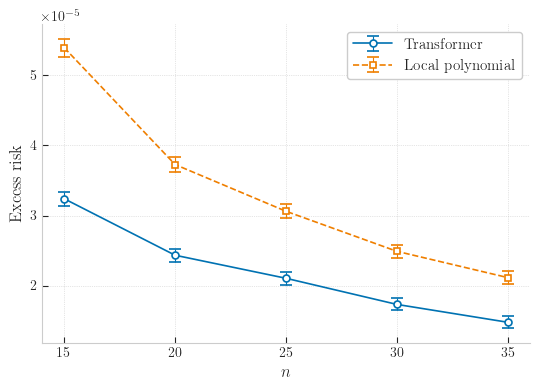

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset":   "stix",           # matches Times in math mode
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "xtick.major.width":  0.8,
    "ytick.major.width":  0.8,
    "axes.grid":          True,
    "grid.linestyle":     ":",
    "grid.linewidth":     0.5,
    "grid.alpha":         0.6,
    "grid.color":         "#aaaaaa",
    "legend.frameon":     True,
    "legend.edgecolor":   "#cccccc",
    "legend.framealpha":  1.0,
    "legend.fontsize":    11,
    "legend.handlelength": 2.5,
})

# Colorblind-safe palette 
BLUE   = "#0072B2"
ORANGE = "#EF7F00"

ns = [15, 20, 25, 30, 35]
z  = 1.645   # 90 % CI

fig, ax = plt.subplots(figsize=(5.5, 4.0))

ax.errorbar(
    ns, loss, yerr=z * loss_se,
    fmt="o-", color=BLUE, markerfacecolor="white", markeredgecolor=BLUE,
    markeredgewidth=1.2, markersize=5, linewidth=1.2,
    capsize=4, capthick=0.8, elinewidth=0.8,
    label="Transformer",
)
ax.errorbar(
    ns, loss_lp, yerr=z * loss_lp_se,
    fmt="s--", color=ORANGE, markerfacecolor="white", markeredgecolor=ORANGE,
    markeredgewidth=1.2, markersize=5, linewidth=1.2,
    capsize=4, capthick=0.8, elinewidth=0.8,
    label="Local polynomial",
)

ax.set_xlabel(r"$n$", fontsize=12)
ax.set_ylabel("Excess risk", fontsize=12)
ax.set_xticks(ns)
ax.tick_params(labelsize=10)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.yaxis.get_offset_text().set_fontsize(10)

ax.legend(fontsize=11)

fig.tight_layout()
fig.savefig("excess_risk.pdf", dpi=300, bbox_inches="tight")
plt.show()